# **Home Exercise 1 on Text Classification**
Implement a Recurrent Neural Network model (Vanilla RNN, GRU, and LSTM) to predict whether a review is positive or negative.

**Data**: [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews) (the last 10% of rows serve as the test set).
Compare the performance of the three models.


In [29]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
import os
import sys
import numpy as np
import pandas as pd

import re
from collections import Counter
import matplotlib.pyplot as plt
from datetime import datetime

print("The last time this project was run is:", datetime.now().strftime("%H:%M:%S %d/%m/%Y"))


if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    print(f"Using device: CUDA - {gpu_name}")
    print(f"CUDA Capability: {torch.cuda.get_device_capability(0)}")
else:
    device = torch.device("cpu")
    print("Using device: CPU (CUDA is not available)")


The last time this project was run is: 18:38:39 20/11/2025
Using device: CUDA - Tesla T4
CUDA Capability: (7, 5)


### Download dataset

In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [19]:
!ls /kaggle/input/imdb-dataset-of-50k-movie-reviews

'IMDB Dataset.csv'


In [3]:
# Hyperparameter
MAX_VOCAB_SIZE = 25000
MAX_SEQ_LEN = 200
BATCH_SIZE = 64
EMBEDDING_DIM = 100
HIDDEN_DIM = 256
OUTPUT_DIM = 1
N_LAYERS = 2
DROPOUT = 0.5
LEARNING_RATE = 1e-3
NUM_EPOCHS = 5

## Loading data with DataLoader into DataFrame

In [21]:
df = pd.read_csv("/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")

In [22]:
df.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [27]:
from sklearn.model_selection import train_test_split

df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(f"Tổng số mẫu dữ liệu: {len(df)}")

test_ratio = 0.1
test_size = int(len(df) * test_ratio)

remaining_df = df.iloc[:-test_size]
test_df = df.iloc[-test_size:]


train_df, val_df = train_test_split(
    remaining_df, 
    test_size=1/9,
    random_state=42,
    shuffle=True,
    stratify=remaining_df['sentiment']
)

print("-" * 30)
print(f"Train Set: {len(train_df)} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val Set:   {len(val_df)} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test Set:  {len(test_df)} samples ({len(test_df)/len(df)*100:.1f}%)")
print("-" * 30)

Tổng số mẫu dữ liệu: 50000
------------------------------
Train Set: 40000 samples (80.0%)
Val Set:   5000 samples (10.0%)
Test Set:  5000 samples (10.0%)
------------------------------


### Preprocessing data

In [23]:
import nltk
from tqdm import tqdm
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [15]:
def preprocessing(text):
    soup = BeautifulSoup(text, 'html.parser')
    text = soup.get_text()
    
    # Remove URL and Email
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S*@\S*\s?', '', text)
    
    # Remove uncommon character
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # Lowercase
    text = text.lower()
    
    # Split into tokens
    tokens = text.split()
    
    # Remove stopwords and lemmatization
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    
    if 'not' in stop_words:
        stop_words.remove('not')
        
    clean_tokens = [
        lemmatizer.lemmatize(token) 
        for token in tokens 
        if token not in stop_words and len(token) > 2 # Bỏ từ quá ngắn
    ]
    
    return clean_tokens

In [ ]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, vocab=None, max_len=MAX_SEQ_LEN, is_train=True, max_vocab_size=MAX_VOCAB_SIZE):
        """
        Args:
            texts (list/np.array): Danh sách các câu review gốc.
            labels (list/np.array): Danh sách nhãn (0 hoặc 1).
            vocab (dict, optional): Từ điển ánh xạ word->index. Nếu là None (tập train), sẽ tự build.
            max_len (int): Độ dài cố định của chuỗi vector.
            is_train (bool): Cờ đánh dấu là tập train hay test.
        """
        self.labels = torch.tensor(labels, dtype=torch.float)
        self.max_len = max_len
        
        # Step 1: Data preprocessing
        self.processed_texts = [preprocessing(text) for text in tqdm(texts)]
        
        # Step 2: Building vocabulary
        if is_train:
            self.vocab = self.build_vocab(self.processed_texts, max_vocab_size)
        else:
            if vocab is None:
                raise ValueError("Dataset Test/Val can phai duoc cung cap vocab tu tap Train!")
            self.vocab = vocab
            
        # Step 3: Vectorization
        self.sequences = [self.text_to_sequence(tokens) for tokens in self.processed_texts]
            
    def build_vocab(self, processed_texts, max_vocab_size):
        all_tokens = []
        for tokens in processed_texts:
            all_tokens.extend(tokens)
        
        count = Counter(all_tokens)
        sorted_words = count.most_common(max_vocab_size)
        
        # <PAD> = 0, <UNK> = 1
        vocab = {w: i+2 for i, (w, c) in enumerate(sorted_words)}
        vocab['<PAD>'] = 0
        vocab['<UNK>'] = 1
        print(f"Vocabulary size: {len(vocab)}")
        return vocab
    
    def text_to_sequence(self, tokens):
        """
        Chuyển list các tokens thành list các indices
        """
        seq = [self.vocab.get(token, 1) for token in tokens]

        if len(seq) < self.max_len:
            seq = seq + [0] * (self.max_len - len(seq))
        else:
            seq = seq[:self.max_len]
            
        return torch.tensor(seq, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

### Data preparation

In [28]:
train_dataset = IMDBDataset(
	texts=train_df['review'].values,
 	labels=train_df['sentiment'].values,
	is_train=True,
	max_vocab_size=MAX_VOCAB_SIZE
)

vocab = train_dataset.vocab

val_dataset = IMDBDataset(
	texts=val_df['review'].values,
	labels=val_df['sentiment'].values,
	vocab=vocab,
	is_train=False
)
test_dataset = IMDBDataset(
    texts=test_df['review'].values, 
    labels=test_df['sentiment'].values, 
    vocab=vocab, 
    is_train=False
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 40000/40000 [00:38<00:00, 1048.60it/s]


Vocabulary size: 25002


100%|██████████| 5000/5000 [00:05<00:00, 960.96it/s] 


## Build models

In [30]:
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super(AttentionLayer, self).__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, rnn_outputs):
        energy = torch.tanh(self.attn(rnn_outputs))
        attn_weights = F.softmax(energy, dim=1) 
        context_vector = torch.sum(rnn_outputs * attn_weights, dim=1)
        
        return context_vector, attn_weights.squeeze(2)

In [31]:
class RecurrentClassifierWithAttention(nn.Module):
    """
    Embedding -> Bi-RNN -> Attention + Last Hidden -> FC -> Output
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout, model_type='LSTM'):
        super().__init__()
        self.model_type = model_type
        
        # Embedding
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # Recurrent Layer
        rnn_args = {
            'input_size': embedding_dim,
            'hidden_size': hidden_dim,
            'num_layers': n_layers,
            'bidirectional': True,
            'dropout': dropout if n_layers > 1 else 0,
            'batch_first': True
        }
        
        if model_type == 'LSTM':
            self.rnn = nn.LSTM(**rnn_args)
        elif model_type == 'GRU':
            self.rnn = nn.GRU(**rnn_args)
        else:
            self.rnn = nn.RNN(**rnn_args)

        self.attention = AttentionLayer(hidden_dim * 2)
        self.fc = nn.Linear(hidden_dim * 4, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text):
        # text: [batch, seq_len]
        embedded = self.dropout(self.embedding(text))
        
        # RNN processing
        if self.model_type == 'LSTM':
            output, (hidden, cell) = self.rnn(embedded)
        else:
            output, hidden = self.rnn(embedded)
            
        hidden_forward = hidden[-2,:,:]
        hidden_backward = hidden[-1,:,:]
        hidden_final = torch.cat((hidden_forward, hidden_backward), dim=1)
        # hidden_final shape: [Batch, Hidden_Dim * 2]
        
        context_vector, attn_weights = self.attention(output)
        combined = torch.cat((hidden_final, context_vector), dim=1)
        # combined shape: [Batch, Hidden_Dim * 4]
        
        return self.fc(self.dropout(combined))

## Configuration the training

In [33]:
def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float() 
    acc = correct.sum() / len(correct)
    return acc

def train_epoch(model, iterator, optimizer, criterion):
    model.train()
    epoch_loss = 0
    epoch_acc = 0
    
    for text, label in iterator:
        text, label = text.to(device), label.to(device)
        
        optimizer.zero_grad()
        predictions = model(text).squeeze(1)
        
        loss = criterion(predictions, label)
        acc = binary_accuracy(predictions, label)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc += acc.item()
        
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0
    epoch_acc = 0
    
    with torch.no_grad():
        for text, label in iterator:
            text, label = text.to(device), label.to(device)
            
            predictions = model(text).squeeze(1)
            
            loss = criterion(predictions, label)
            acc = binary_accuracy(predictions, label)
            epoch_loss += loss.item()
            epoch_acc += acc.item()
            
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

### Hyperparameter of training loops

In [37]:
import datetime

In [ ]:
EMBEDDING_DIM = 100
HIDDEN_DIM = 256
OUTPUT_DIM = 1
N_LAYERS = 2
DROPOUT = 0.5
LEARNING_RATE = 1e-3
NUM_EPOCHS = 30

history = {
    'RNN': {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'test_acc': 0, 'test_loss': 0, 'time': 0
    },
    'GRU': {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'test_acc': 0, 'test_loss': 0, 'time': 0
    },
    'LSTM': {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'test_acc': 0, 'test_loss': 0, 'time': 0
    }
}

criterion = nn.BCEWithLogitsLoss().to(device)

In [40]:
# Config Early Stopping
PATIENCE = 3

for model_type in ['RNN', 'GRU', 'LSTM']:
    print(f"Training: {model_type} ...")
    model = RecurrentClassifierWithAttention(
        vocab_size=len(vocab),
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        output_dim=OUTPUT_DIM,
        n_layers=N_LAYERS,
        dropout=DROPOUT,
        model_type=model_type
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    start_time = datetime.datetime.now()
    best_valid_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        valid_loss, valid_acc = evaluate(model, val_loader, criterion)
        
        history[model_type]['train_loss'].append(train_loss)
        history[model_type]['train_acc'].append(train_acc)
        history[model_type]['val_loss'].append(valid_loss)
        history[model_type]['val_acc'].append(valid_acc)

        # Early Stopping Logic
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), f'{model_type}_best_model.pt')
            patience_counter = 0
        else:
            patience_counter += 1
            
        print(f'\tEpoch {epoch+1:02d} | '
              f'Train loss: {train_loss:.3f} Train acc: {train_acc*100:.1f}% | '
              f'Val loss: {valid_loss:.3f} Val acc: {valid_acc*100:.1f}%')
        
        if patience_counter >= PATIENCE:
            print(f"\t>>> Early Stopping tại epoch {epoch+1}")
            break
    
    end_time = datetime.datetime.now()
    history[model_type]['time'] = (end_time - start_time).total_seconds()
    
    # Test final
    model.load_state_dict(torch.load(f'{model_type}_best_model.pt'))
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    history[model_type]['test_acc'] = test_acc
    history[model_type]['test_loss'] = test_loss
    
    print(f"{model_type} completed | "
          f"Test acc: {test_acc*100:.2f}% Loss: {test_loss:.3f} | "
          f"Time: {history[model_type]['time']:.1f}s")

Training: RNN ...
	Epoch 01 | Train Loss: 0.705 Acc: 52.9% | Val Loss: 0.685 Acc: 54.8%
	Epoch 02 | Train Loss: 0.708 Acc: 52.4% | Val Loss: 0.694 Acc: 53.1%
	Epoch 03 | Train Loss: 0.703 Acc: 53.3% | Val Loss: 0.671 Acc: 58.7%
	Epoch 04 | Train Loss: 0.694 Acc: 55.9% | Val Loss: 0.663 Acc: 60.6%
	Epoch 05 | Train Loss: 0.671 Acc: 59.9% | Val Loss: 0.649 Acc: 62.4%
	Epoch 06 | Train Loss: 0.657 Acc: 62.0% | Val Loss: 0.656 Acc: 60.7%
	Epoch 07 | Train Loss: 0.598 Acc: 68.3% | Val Loss: 0.566 Acc: 73.0%
	Epoch 08 | Train Loss: 0.552 Acc: 72.1% | Val Loss: 0.509 Acc: 74.9%
	Epoch 09 | Train Loss: 0.602 Acc: 68.9% | Val Loss: 0.610 Acc: 68.6%
	Epoch 10 | Train Loss: 0.497 Acc: 76.2% | Val Loss: 0.389 Acc: 82.9%
RNN complete | Test Acc: 84.06% Loss: 0.373 | Time: 160.6s
Training: GRU ...
	Epoch 01 | Train Loss: 0.512 Acc: 73.7% | Val Loss: 0.353 Acc: 84.8%
	Epoch 02 | Train Loss: 0.359 Acc: 84.3% | Val Loss: 0.300 Acc: 87.4%
	Epoch 03 | Train Loss: 0.306 Acc: 87.0% | Val Loss: 0.289 Acc: 8

In [41]:
import matplotlib.pyplot as plt
import numpy as np

def plot_overfitting_analysis(history):
    plt.style.use('seaborn-v0_8-whitegrid')
    
    fig = plt.figure(figsize=(20, 12))
    plt.suptitle('MODEL TRAINING & PERFORMANCE ANALYSIS DASHBOARD', fontsize=16, fontweight='bold', y=0.95)
    
    model_types = ['RNN', 'GRU', 'LSTM']
    c_train = '#2980b9'
    c_val = '#e74c3c'
    c_fill_over = '#e74c3c'
    c_fill_good = '#2ecc71'
    
    for idx, model_type in enumerate(model_types):
        t_loss = history[model_type]['train_loss']
        v_loss = history[model_type]['val_loss']
        t_acc = history[model_type]['train_acc']
        v_acc = history[model_type]['val_acc']
        epochs = range(1, len(t_loss) + 1)
        
        ax1 = plt.subplot(3, 3, idx + 1)
        ax1.plot(epochs, t_loss, label='Train Loss', color=c_train, linewidth=2, linestyle='-')
        ax1.plot(epochs, v_loss, label='Val Loss', color=c_val, linewidth=2, linestyle='--')
        
        ax1.fill_between(epochs, t_loss, v_loss, where=np.array(v_loss) >= np.array(t_loss), 
                         facecolor=c_fill_over, alpha=0.2, interpolate=True, label='Overfitting Gap')
        
        best_epoch = np.argmin(v_loss) + 1
        best_val_loss = min(v_loss)
        ax1.scatter(best_epoch, best_val_loss, s=100, c='gold', edgecolors='black', zorder=10, label='Best Checkpoint')
        ax1.annotate(f'Best: {best_val_loss:.3f}', (best_epoch, best_val_loss), 
                     xytext=(0, 10), textcoords='offset points', ha='center', fontsize=8, fontweight='bold')

        ax1.set_title(f'{model_type} - Loss Dynamics', fontweight='bold')
        ax1.set_ylabel('Loss')
        if idx == 0: ax1.legend(loc='upper right', frameon=True)
        
        ax2 = plt.subplot(3, 3, idx + 4)
        ax2.plot(epochs, t_acc, label='Train Acc', color=c_train, linewidth=2)
        ax2.plot(epochs, v_acc, label='Val Acc', color=c_val, linewidth=2, linestyle='--')
        
        max_epoch = np.argmax(v_acc) + 1
        max_val_acc = max(v_acc)
        ax2.scatter(max_epoch, max_val_acc, s=100, c='gold', edgecolors='black', zorder=10)
        ax2.text(max_epoch, max_val_acc + 0.01, f'{max_val_acc*100:.1f}%', ha='center', fontsize=8, fontweight='bold')

        ax2.set_title(f'{model_type} - Accuracy Dynamics', fontweight='bold')
        ax2.set_ylabel('Accuracy')
        ax2.set_xlabel('Epochs')
        ax2.set_ylim([0.4, 1.0])
    
    model_names = list(history.keys())
    colors_bar = ['#34495e', '#3498db', '#2ecc71']
    
    ax3 = plt.subplot(3, 3, 7)
    test_accs = [history[m]['test_acc'] for m in model_names]
    bars = ax3.bar(model_names, test_accs, color=colors_bar, edgecolor='black', alpha=0.9)
    ax3.set_ylim([0.7, 1.0])
    ax3.set_title('Final Test Accuracy (Higher is Better)', fontweight='bold')
    
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height, f'{height*100:.2f}%', 
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

    ax4 = plt.subplot(3, 3, 8)
    times = [history[m]['time'] for m in model_names]
    bars = ax4.bar(model_names, times, color=colors_bar, edgecolor='black', alpha=0.9)
    ax4.set_title('Total Training Time (Lower is Better)', fontweight='bold')
    
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}s', 
                 ha='center', va='bottom', fontweight='bold')

    ax5 = plt.subplot(3, 3, 9)
    gaps = []
    for m in model_names:
        idx_best = np.argmin(history[m]['val_loss'])
        gap = history[m]['val_loss'][idx_best] - history[m]['train_loss'][idx_best]
        gaps.append(gap)
        
    colors_gap = ['#2ecc71' if g < 0.05 else '#f1c40f' if g < 0.1 else '#e74c3c' for g in gaps]
    bars = ax5.bar(model_names, gaps, color=colors_gap, edgecolor='black', alpha=0.9)
    
    ax5.axhline(y=0, color='black', linewidth=1)
    ax5.axhline(y=0.1, color='red', linestyle=':', label='Danger Zone')
    ax5.set_title('Generalization Gap (Lower is Better)', fontweight='bold')
    
    for bar, val in zip(bars, gaps):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + 0.005 if height > 0 else height - 0.01, 
                 f'{val:.3f}', ha='center', va='bottom' if height > 0 else 'top', fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('advanced_analysis_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_overfitting_report(history):
    print("\n" + "█"*80)
    print("   FINAL EVALUATION REPORT")
    print("█"*80)
    
    print(f"{'MODEL':<10} | {'TEST ACC':<12} | {'TIME (s)':<10} | {'STATUS':<20} | {'RECOMMENDATION'}")
    print("-" * 80)
    
    for m in history.keys():
        best_idx = np.argmin(history[m]['val_loss'])
        val_loss = history[m]['val_loss'][best_idx]
        train_loss = history[m]['train_loss'][best_idx]
        test_acc = history[m]['test_acc']
        time_taken = history[m]['time']
        
        gap = val_loss - train_loss
        
        if gap > 0.1:
            status = "OVERFITTING"
            rec = "Increase Dropout"
        elif gap < -0.02:
            status = "UNDERFITTING"
            rec = "Train longer/More layers"
        else:
            status = "GOOD FIT"
            rec = "Deploy Model"
            
        print(f"{m:<10} | {test_acc*100:<6.2f}%      | {time_taken:<10.1f} | {status:<20} | {rec}")
    print("-" * 80 + "\n")

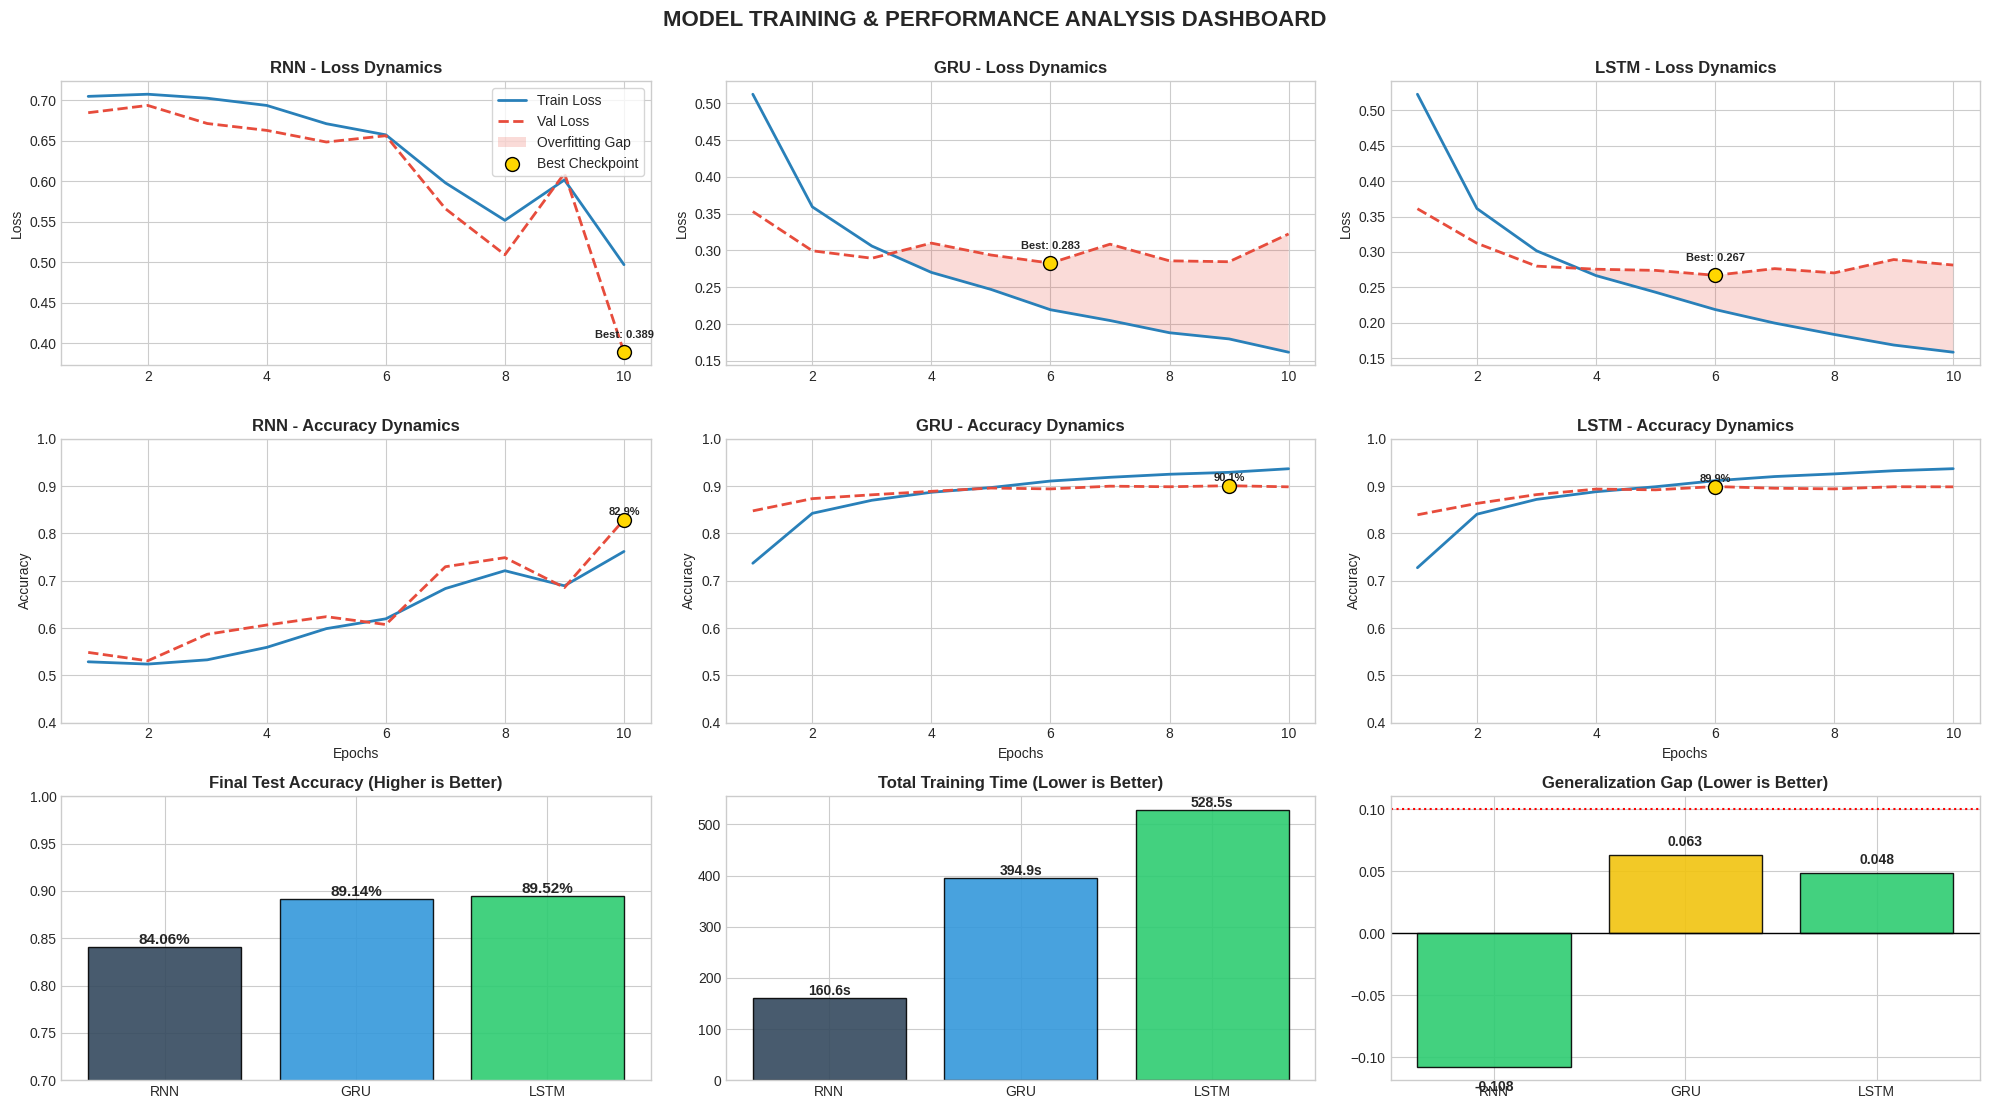


████████████████████████████████████████████████████████████████████████████████
   FINAL EVALUATION REPORT
████████████████████████████████████████████████████████████████████████████████
MODEL      | TEST ACC     | TIME (s)   | STATUS               | RECOMMENDATION
--------------------------------------------------------------------------------
RNN        | 84.06 %      | 160.6      | UNDERFITTING         | Train longer/More layers
GRU        | 89.14 %      | 394.9      | GOOD FIT             | Deploy Model
LSTM       | 89.52 %      | 528.5      | GOOD FIT             | Deploy Model
--------------------------------------------------------------------------------



In [42]:
plot_overfitting_analysis(history)
print_overfitting_report(history)